## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Folder utama penyimpanan
import os
DRIVE_PATH = '/content/drive/MyDrive/Skripsi_Faris'
os.makedirs(DRIVE_PATH, exist_ok=True)
print("Google Drive berhasil di-mount. Folder:", DRIVE_PATH)

Mounted at /content/drive
Google Drive berhasil di-mount. Folder: /content/drive/MyDrive/Skripsi_Faris


## Install Library

In [2]:
!pip install google-play-scraper wordcloud Sastrawi nltk transformers torch datasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 20.1 MB/s eta 0:00:00


## 1. Scraping

In [3]:
from google_play_scraper import Sort, reviews_all
import pandas as pd
import numpy as np

result = reviews_all(
    'com.larus.wolf',
    sleep_milliseconds=0,
    lang='id',
    country='id',
    count=10000,
    sort=Sort.NEWEST,
)

df_busu = pd.DataFrame(np.array(result), columns=['review'])
df_busu = df_busu.join(pd.DataFrame(df_busu.pop('review').tolist()))
df_busu = df_busu.head(10000)

my_df = df_busu[['userName', 'score', 'at', 'content']].sort_values(by='at', ascending=False)
my_df = my_df[['userName', 'score', 'at', 'content']]

print("=== HASIL SCRAPING ===")
print(f"Jumlah data hasil scraping : {len(my_df)}")
print(f"Missing value content      : {my_df['content'].isnull().sum()}")
print()
my_df.head(10)

=== HASIL SCRAPING ===
Jumlah data hasil scraping : 10000
Missing value content      : 0



,userName,score,at,content
0,Pengguna Google,5,2026-09-04 13:11:04,dola sangat membantu saat kita butuh jawaban
1,Pengguna Google,5,2026-09-04 13:05:43,aku sukaa
2,Pengguna Google,5,2026-09-04 13:05:11,sangat baik
3,Pengguna Google,5,2026-09-04 13:03:44,bagus
4,Pengguna Google,5,2026-09-04 13:02:40,baik
5,Pengguna Google,5,2026-09-04 12:59:50,cocok banget untuk tempat curhat nanyak nanyak
6,Pengguna Google,5,2026-09-04 12:58:10,Dola memang keren👍👍👍🙏🙏❤️❤️
7,Pengguna Google,4,2026-09-04 12:57:39,masih kurang memenuhi permintaan
8,Pengguna Google,5,2026-09-04 12:56:47,dola sangat baik bagi ku🥺
9,Pengguna Google,5,2026-09-04 12:55:08,sangat memuaskan


In [4]:
# Simpan hasil scraping ke Google Drive
SCRAPING_PATH = f'{DRIVE_PATH}/1_scrapped_data.csv'
my_df.to_csv(SCRAPING_PATH, index=False)
print(f"Hasil scraping disimpan di: {SCRAPING_PATH}")

Hasil scraping disimpan di: /content/drive/MyDrive/Skripsi_Faris/1_scrapped_data.csv


## 2. Labelling

In [5]:
# Labelling berdasarkan teks menggunakan pendekatan bigram
import re

kata_negasi = ['tidak', 'kurang', 'belum', 'gak', 'ga', 'nggak', 'ngga', 'tak', 'bukan']

kata_positif = [
    'bagus', 'baik', 'mantap', 'keren', 'suka', 'senang', 'puas', 'membantu',
    'mudah', 'nyaman', 'canggih', 'hebat', 'top', 'menarik', 'cepat', 'lancar',
    'memuaskan', 'terbaik', 'sempurna', 'berguna', 'bermanfaat', 'responsif',
    'recommended', 'rekomen', 'oke', 'ok', 'luar biasa', 'kece'
]

kata_negatif = [
    'buruk', 'jelek', 'lambat', 'lemot', 'error', 'bug', 'crash', 'susah',
    'sulit', 'kecewa', 'gagal', 'mengecewakan', 'parah', 'payah', 'sampah',
    'boros', 'gangguan', 'rusak', 'berbayar', 'mahal', 'iklan', 'spam',
    'ribet', 'membingungkan', 'zonk', 'bohong', 'tipu'
]

def normalisasi_teks(teks):
    teks = str(teks).lower()
    teks = re.sub(r'http\S+|www\S+', '', teks)
    teks = re.sub(r'[^\w\s]', ' ', teks)   # tanda baca diganti spasi, bukan dihapus
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

def pelabelan_teks(teks):
    if pd.isna(teks) or str(teks).strip() == '':
        return None

    words = normalisasi_teks(teks).split()
    if not words:
        return None

    skor_positif = 0
    skor_negatif = 0
    i = 0
    n = len(words)
    while i < n:
        matched = False
        if i < n - 1:
            frasa = words[i] + ' ' + words[i+1]
            if frasa in kata_positif or frasa in kata_negatif:
                ada_negasi = (i > 0 and words[i-1] in kata_negasi)
                if frasa in kata_positif:
                    skor_positif += 0 if ada_negasi else 1
                    skor_negatif += 1 if ada_negasi else 0
                else:
                    skor_negatif += 0 if ada_negasi else 1
                    skor_positif += 1 if ada_negasi else 0
                i += 2
                matched = True
        if not matched:
            word = words[i]
            ada_negasi = (i > 0 and words[i-1] in kata_negasi)
            if word in kata_positif:
                skor_positif += 0 if ada_negasi else 1
                skor_negatif += 1 if ada_negasi else 0
            elif word in kata_negatif:
                skor_negatif += 0 if ada_negasi else 1
                skor_positif += 1 if ada_negasi else 0
            i += 1

    if skor_positif > skor_negatif:
        return 'Positif'
    elif skor_negatif > skor_positif:
        return 'Negatif'
    else:
        return 'Netral'

my_df['Label'] = my_df['content'].apply(pelabelan_teks)

print("=== HASIL LABELLING ===")
print(my_df['Label'].value_counts())
print(f"\nTotal data berlabel : {my_df['Label'].notna().sum()}")
print(f"Data tanpa label    : {my_df['Label'].isna().sum()}")
print()
my_df.head(10)

=== HASIL LABELLING ===
Label
Positif    6393
Netral     3213
Negatif     262
Name: count, dtype: int64

Total data berlabel : 9868
Data tanpa label    : 132



,userName,score,at,content,Label
0,Pengguna Google,5,2026-09-04 13:11:04,dola sangat membantu saat kita butuh jawaban,Positif
1,Pengguna Google,5,2026-09-04 13:05:43,aku sukaa,Netral
2,Pengguna Google,5,2026-09-04 13:05:11,sangat baik,Positif
3,Pengguna Google,5,2026-09-04 13:03:44,bagus,Positif
4,Pengguna Google,5,2026-09-04 13:02:40,baik,Positif
5,Pengguna Google,5,2026-09-04 12:59:50,cocok banget untuk tempat curhat nanyak nanyak,Netral
6,Pengguna Google,5,2026-09-04 12:58:10,Dola memang keren👍👍👍🙏🙏❤️❤️,Positif
7,Pengguna Google,4,2026-09-04 12:57:39,masih kurang memenuhi permintaan,Netral
8,Pengguna Google,5,2026-09-04 12:56:47,dola sangat baik bagi ku🥺,Positif
9,Pengguna Google,5,2026-09-04 12:55:08,sangat memuaskan,Positif


In [6]:
# Simpan hasil labelling ke Google Drive
LABELLING_PATH = f'{DRIVE_PATH}/2_labelled_data.csv'
my_df.to_csv(LABELLING_PATH, index=False)
print(f"Hasil labelling disimpan di: {LABELLING_PATH}")

Hasil labelling disimpan di: /content/drive/MyDrive/Skripsi_Faris/2_labelled_data.csv


## 3. Cleaning Data

In [7]:
import pandas as pd
import re

pd.set_option('display.max_columns', None)
my_df = pd.read_csv(LABELLING_PATH)

print("=== SEBELUM CLEANING ===")
print(f"Jumlah data          : {len(my_df)}")
print(f"Missing value content: {my_df['content'].isnull().sum()}")
print(f"Missing value Label  : {my_df['Label'].isnull().sum()}")

# 1. Menghapus baris dengan content null atau string kosong
my_df.dropna(subset=['content'], inplace=True)
my_df = my_df[my_df['content'].str.strip() != '']

# 2. Menghapus baris dengan Label null
my_df.dropna(subset=['Label'], inplace=True)

# 3. Menghapus duplikat berdasarkan kolom content
jumlah_sebelum = len(my_df)
my_df.drop_duplicates(subset=['content'], inplace=True)
jumlah_duplikat = jumlah_sebelum - len(my_df)
print(f"\nJumlah duplikat yang dihapus : {jumlah_duplikat}")

# 4. Membersihkan isi teks ulasan
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)          # hapus URL
    text = re.sub(r'[@#$%^&*]', '', text)                 # hapus simbol @, #, $, %, dll
    text = re.sub(r'[^\w\s]', '', text)                  # hapus tanda baca (.,!? dll)
    text = re.sub(r'\d+', '', text)                       # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()              # hapus spasi berlebih
    return text

my_df['content'] = my_df['content'].apply(clean_text)

# 5. Hapus baris yang jadi kosong setelah cleaning
my_df = my_df[my_df['content'].str.strip() != '']

print("\n=== HASIL CLEANING ===")
print(f"Jumlah data setelah cleaning : {len(my_df)}")
print(f"Missing value content        : {my_df['content'].isnull().sum()}")
print(f"Missing value Label          : {my_df['Label'].isnull().sum()}")
print()
print("Contoh hasil cleaning:")
my_df[['content', 'Label']].head(10)

=== SEBELUM CLEANING ===
Jumlah data          : 10000
Missing value content: 0
Missing value Label  : 132

Jumlah duplikat yang dihapus : 2312

=== HASIL CLEANING ===
Jumlah data setelah cleaning : 7553
Missing value content        : 0
Missing value Label          : 0

Contoh hasil cleaning:


,content,Label
0,dola sangat membantu saat kita butuh jawaban,Positif
1,aku sukaa,Netral
2,sangat baik,Positif
3,bagus,Positif
4,baik,Positif
5,cocok banget untuk tempat curhat nanyak nanyak,Netral
6,Dola memang keren,Positif
7,masih kurang memenuhi permintaan,Netral
8,dola sangat baik bagi ku,Positif
9,sangat memuaskan,Positif


In [8]:
# Simpan hasil cleaning ke Google Drive
CLEANING_PATH = f'{DRIVE_PATH}/3_cleaned_data.csv'
my_df.to_csv(CLEANING_PATH, index=False)
print(f"Hasil cleaning disimpan di: {CLEANING_PATH}")

Hasil cleaning disimpan di: /content/drive/MyDrive/Skripsi_Faris/3_cleaned_data.csv


## 4. Case Folding

In [9]:
# Case Folding: hanya mengubah huruf besar menjadi huruf kecil
my_df['text_clean'] = my_df['content'].str.lower()

print("=== HASIL CASE FOLDING ===")
print(f"Jumlah data : {len(my_df)}")
print()
my_df[['content', 'text_clean']].head(10)

=== HASIL CASE FOLDING ===
Jumlah data : 7553



,content,text_clean
0,dola sangat membantu saat kita butuh jawaban,dola sangat membantu saat kita butuh jawaban
1,aku sukaa,aku sukaa
2,sangat baik,sangat baik
3,bagus,bagus
4,baik,baik
5,cocok banget untuk tempat curhat nanyak nanyak,cocok banget untuk tempat curhat nanyak nanyak
6,Dola memang keren,dola memang keren
7,masih kurang memenuhi permintaan,masih kurang memenuhi permintaan
8,dola sangat baik bagi ku,dola sangat baik bagi ku
9,sangat memuaskan,sangat memuaskan


In [10]:
# Simpan hasil case folding ke Google Drive
CASEFOLDING_PATH = f'{DRIVE_PATH}/4_casefolding_data.csv'
my_df.to_csv(CASEFOLDING_PATH, index=False)
print(f"Hasil case folding disimpan di: {CASEFOLDING_PATH}")

Hasil case folding disimpan di: /content/drive/MyDrive/Skripsi_Faris/4_casefolding_data.csv


## 5. Stopword Removal

In [11]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop = stopwords.words('indonesian')

my_df['text_StopWord'] = my_df['text_clean'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in stop])
)

print("=== HASIL STOPWORD REMOVAL ===")
print(f"Jumlah data : {len(my_df)}")
print()
my_df[['text_clean', 'text_StopWord']].head(10)

=== HASIL STOPWORD REMOVAL ===
Jumlah data : 7553



,text_clean,text_StopWord
0,dola sangat membantu saat kita butuh jawaban,dola membantu butuh
1,aku sukaa,sukaa
2,sangat baik,
3,bagus,bagus
4,baik,
5,cocok banget untuk tempat curhat nanyak nanyak,cocok banget curhat nanyak nanyak
6,dola memang keren,dola keren
7,masih kurang memenuhi permintaan,memenuhi permintaan
8,dola sangat baik bagi ku,dola ku
9,sangat memuaskan,memuaskan


In [12]:
# Simpan hasil stopword removal ke Google Drive
STOPWORD_PATH = f'{DRIVE_PATH}/5_stopword_data.csv'
my_df.to_csv(STOPWORD_PATH, index=False)
print(f"Hasil stopword removal disimpan di: {STOPWORD_PATH}")

Hasil stopword removal disimpan di: /content/drive/MyDrive/Skripsi_Faris/5_stopword_data.csv


## 6. Word Cloud

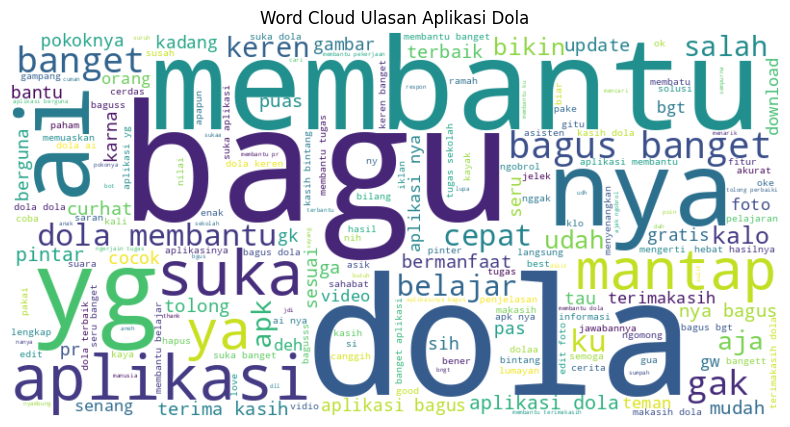

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

data_komentar = ' '.join(my_df['text_StopWord'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(data_komentar)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Ulasan Aplikasi Dola')
plt.show()

## 7. Tokenizing

In [14]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

my_df['text_tokens'] = my_df['text_StopWord'].apply(lambda x: word_tokenize(x))

print("=== HASIL TOKENIZING ===")
print(f"Jumlah data : {len(my_df)}")
print()
my_df[['text_StopWord', 'text_tokens']].head(10)

=== HASIL TOKENIZING ===
Jumlah data : 7553



,text_StopWord,text_tokens
0,dola membantu butuh,"[dola, membantu, butuh]"
1,sukaa,[sukaa]
2,,[]
3,bagus,[bagus]
4,,[]
5,cocok banget curhat nanyak nanyak,"[cocok, banget, curhat, nanyak, nanyak]"
6,dola keren,"[dola, keren]"
7,memenuhi permintaan,"[memenuhi, permintaan]"
8,dola ku,"[dola, ku]"
9,memuaskan,[memuaskan]


In [15]:
# Simpan hasil tokenizing ke Google Drive
TOKENIZING_PATH = f'{DRIVE_PATH}/6_tokenizing_data.csv'
my_df.to_csv(TOKENIZING_PATH, index=False)
print(f"Hasil tokenizing disimpan di: {TOKENIZING_PATH}")

Hasil tokenizing disimpan di: /content/drive/MyDrive/Skripsi_Faris/6_tokenizing_data.csv


## 8. Stemming

In [16]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmed_wrapper(term):
    return stemmer.stem(term)

term_dict = {}
for document in my_df['text_tokens']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)

def get_stemmed_term(document):
    return [term_dict[term] for term in document]

my_df['text_stemindo'] = my_df['text_tokens'].apply(lambda x: ' '.join(get_stemmed_term(x)))

print("=== HASIL STEMMING ===")
print(f"Jumlah data        : {len(my_df)}")
print(f"Jumlah unique term : {len(term_dict)}")
print()
my_df[['text_tokens', 'text_stemindo']].head(10)

=== HASIL STEMMING ===
Jumlah data        : 7553
Jumlah unique term : 6643



,text_tokens,text_stemindo
0,"[dola, membantu, butuh]",dola bantu butuh
1,[sukaa],sukaa
2,[],
3,[bagus],bagus
4,[],
5,"[cocok, banget, curhat, nanyak, nanyak]",cocok banget curhat nanyak nanyak
6,"[dola, keren]",dola keren
7,"[memenuhi, permintaan]",penuh minta
8,"[dola, ku]",dola ku
9,[memuaskan],muas


In [17]:
# Simpan hasil stemming ke Google Drive
STEMMING_PATH = f'{DRIVE_PATH}/7_stemming_data.csv'
my_df.to_csv(STEMMING_PATH, index=False)
print(f"Hasil stemming disimpan di: {STEMMING_PATH}")

Hasil stemming disimpan di: /content/drive/MyDrive/Skripsi_Faris/7_stemming_data.csv
